# Pickle File Viewer (`.pkl`)

This notebook allows you to inspect and visualize the contents of pickle (`.pkl`) files.

> **Why the previous error occurred:**
> `HERA_04-03-2022_all.pkl` (and related radio astronomy datasets) is serialized as a **Python list of NumPy arrays** (`[train_x, train_y, test_x, test_y]`), not a `pandas.DataFrame`. 
> Calling `.head()` on a Python list throws `AttributeError: 'list' object has no attribute 'head'`. This notebook handles lists, dictionaries, NumPy arrays, and DataFrames seamlessly.

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def inspect_pickle(file_path):
    """
    Loads and inspects any pickle file, displaying its type, structure,
    and summary statistics.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return None
    
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"File: {os.path.basename(file_path)} ({file_size_mb:.2f} MB)")
    print("=" * 60)
    
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    
    print(f"Root object type: {type(data)}\n")
    
    if isinstance(data, pd.DataFrame):
        print(f"DataFrame shape: {data.shape}")
        print("\nColumns and Info:")
        print(data.info())
        print("\nFirst 5 rows:")
        display(data.head())
        
    elif isinstance(data, (list, tuple)):
        print(f"Container contains {len(data)} items:")
        print("-" * 60)
        labels = ["train_x (images)", "train_y (masks)", "test_x (images)", "test_y (masks)"]
        for i, item in enumerate(data):
            label = labels[i] if i < len(labels) else f"item_{i}"
            if isinstance(item, np.ndarray):
                is_bool = (item.dtype == bool or np.issubdtype(item.dtype, np.bool_))
                stats = f"min={item.min():.4f}, max={item.max():.4f}, mean={item.mean():.4f}"
                if is_bool:
                    stats += f" ({100 * item.mean():.2f}% True / RFI flagged)"
                print(f"  [{i}] {label:<20} | ndarray shape={item.shape} dtype={item.dtype} | {stats}")
            elif isinstance(item, (list, tuple)):
                print(f"  [{i}] {label:<20} | {type(item).__name__} of length {len(item)}")
            else:
                print(f"  [{i}] {label:<20} | {type(item).__name__}: {repr(item)[:60]}")
                
    elif isinstance(data, dict):
        print(f"Dictionary keys ({len(data)} total):")
        print("-" * 60)
        for k, v in list(data.items())[:20]:
            if isinstance(v, np.ndarray):
                print(f"  '{k}': ndarray shape={v.shape}, dtype={v.dtype}")
            elif isinstance(v, (list, tuple)):
                print(f"  '{k}': {type(v).__name__} len={len(v)}")
            else:
                print(f"  '{k}': {type(v).__name__} = {repr(v)[:60]}")
                
    elif isinstance(data, np.ndarray):
        print(f"NumPy array: shape={data.shape}, dtype={data.dtype}")
        print(f"min={data.min()}, max={data.max()}, mean={data.mean():.4f}")
        
    return data


### 1. Load and Inspect Pickle File
Set the target file path and run inspection below:

In [3]:
# Path to the pickle file to inspect
pkl_file = "HERA_04-03-2022_all.pkl"

# Load and inspect structure
data = inspect_pickle(pkl_file)


File: HERA_04-03-2022_all.pkl (420.00 MB)
Root object type: <class 'list'>

Container contains 4 items:
------------------------------------------------------------
  [0] train_x (images)     | ndarray shape=(420, 512, 512, 1) dtype=float16 | min=0.0000, max=427.7500, mean=10.9141
  [1] train_y (masks)      | ndarray shape=(420, 512, 512, 1) dtype=bool | min=0.0000, max=1.0000, mean=0.0277 (2.77% True / RFI flagged)
  [2] test_x (images)      | ndarray shape=(140, 512, 512, 1) dtype=float16 | min=0.0000, max=404.2500, mean=11.8516
  [3] test_y (masks)       | ndarray shape=(140, 512, 512, 1) dtype=bool | min=0.0000, max=1.0000, mean=0.0275 (2.75% True / RFI flagged)


### 2. Visualize Spectrogram and RFI Mask (Single Sample)
For datasets containing spectrograms and masks (e.g. `HERA_04-03-2022_all.pkl`), this plots the raw observation spectrogram, the ground truth RFI mask, and their overlay.

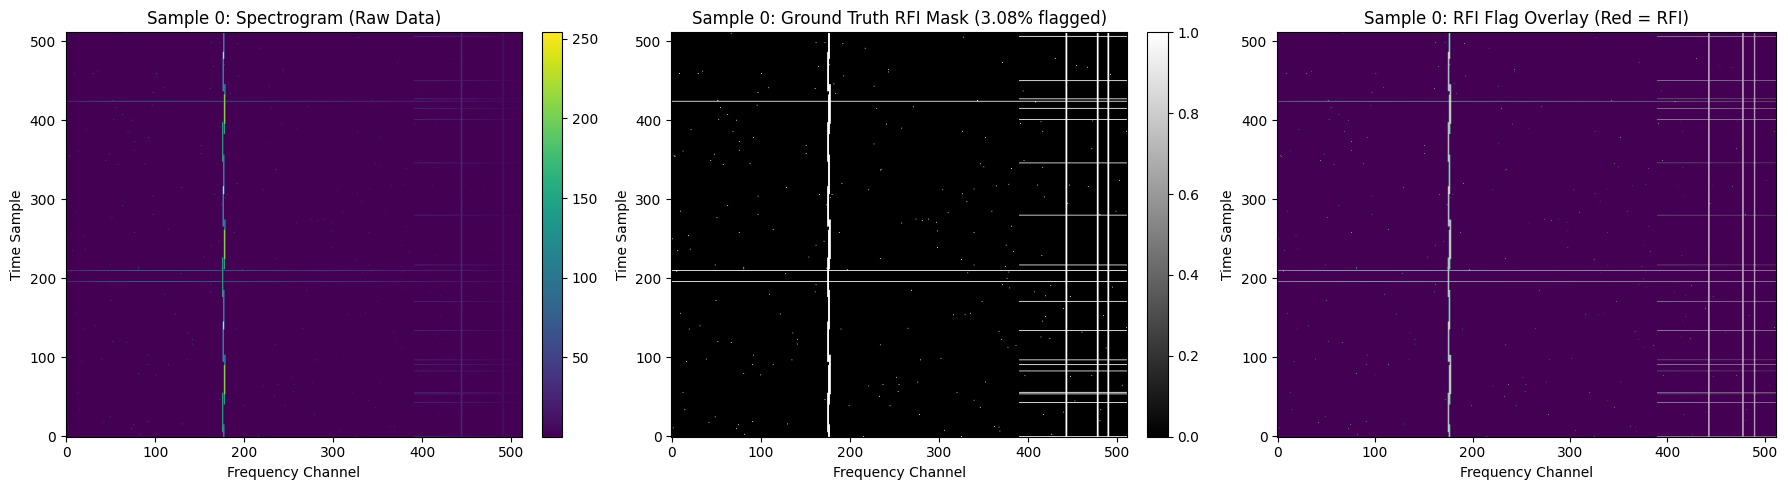

In [4]:
if isinstance(data, (list, tuple)) and len(data) >= 2 and isinstance(data[0], np.ndarray):
    train_x, train_y = data[0], data[1]
    
    # Select sample index to visualize
    sample_idx = 0
    
    img = train_x[sample_idx].squeeze()
    mask = train_y[sample_idx].squeeze()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Spectrogram
    im0 = axes[0].imshow(img, aspect="auto", cmap="viridis", origin="lower")
    axes[0].set_title(f"Sample {sample_idx}: Spectrogram (Raw Data)")
    axes[0].set_xlabel("Frequency Channel")
    axes[0].set_ylabel("Time Sample")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Ground Truth Mask
    im1 = axes[1].imshow(mask, aspect="auto", cmap="gray", origin="lower")
    axes[1].set_title(f"Sample {sample_idx}: Ground Truth RFI Mask ({100*mask.mean():.2f}% flagged)")
    axes[1].set_xlabel("Frequency Channel")
    axes[1].set_ylabel("Time Sample")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(img, aspect="auto", cmap="viridis", origin="lower")
    axes[2].imshow(np.ma.masked_where(~mask.astype(bool), mask), aspect="auto", cmap="Reds", alpha=0.6, origin="lower")
    axes[2].set_title(f"Sample {sample_idx}: RFI Flag Overlay (Red = RFI)")
    axes[2].set_xlabel("Frequency Channel")
    axes[2].set_ylabel("Time Sample")
    
    plt.tight_layout()
    plt.show()
else:
    print("Dataset structure is not a list of [images, masks, ...]. Check inspection output above.")


### 3. Multi-Sample Overview
View multiple samples across the dataset side-by-side.

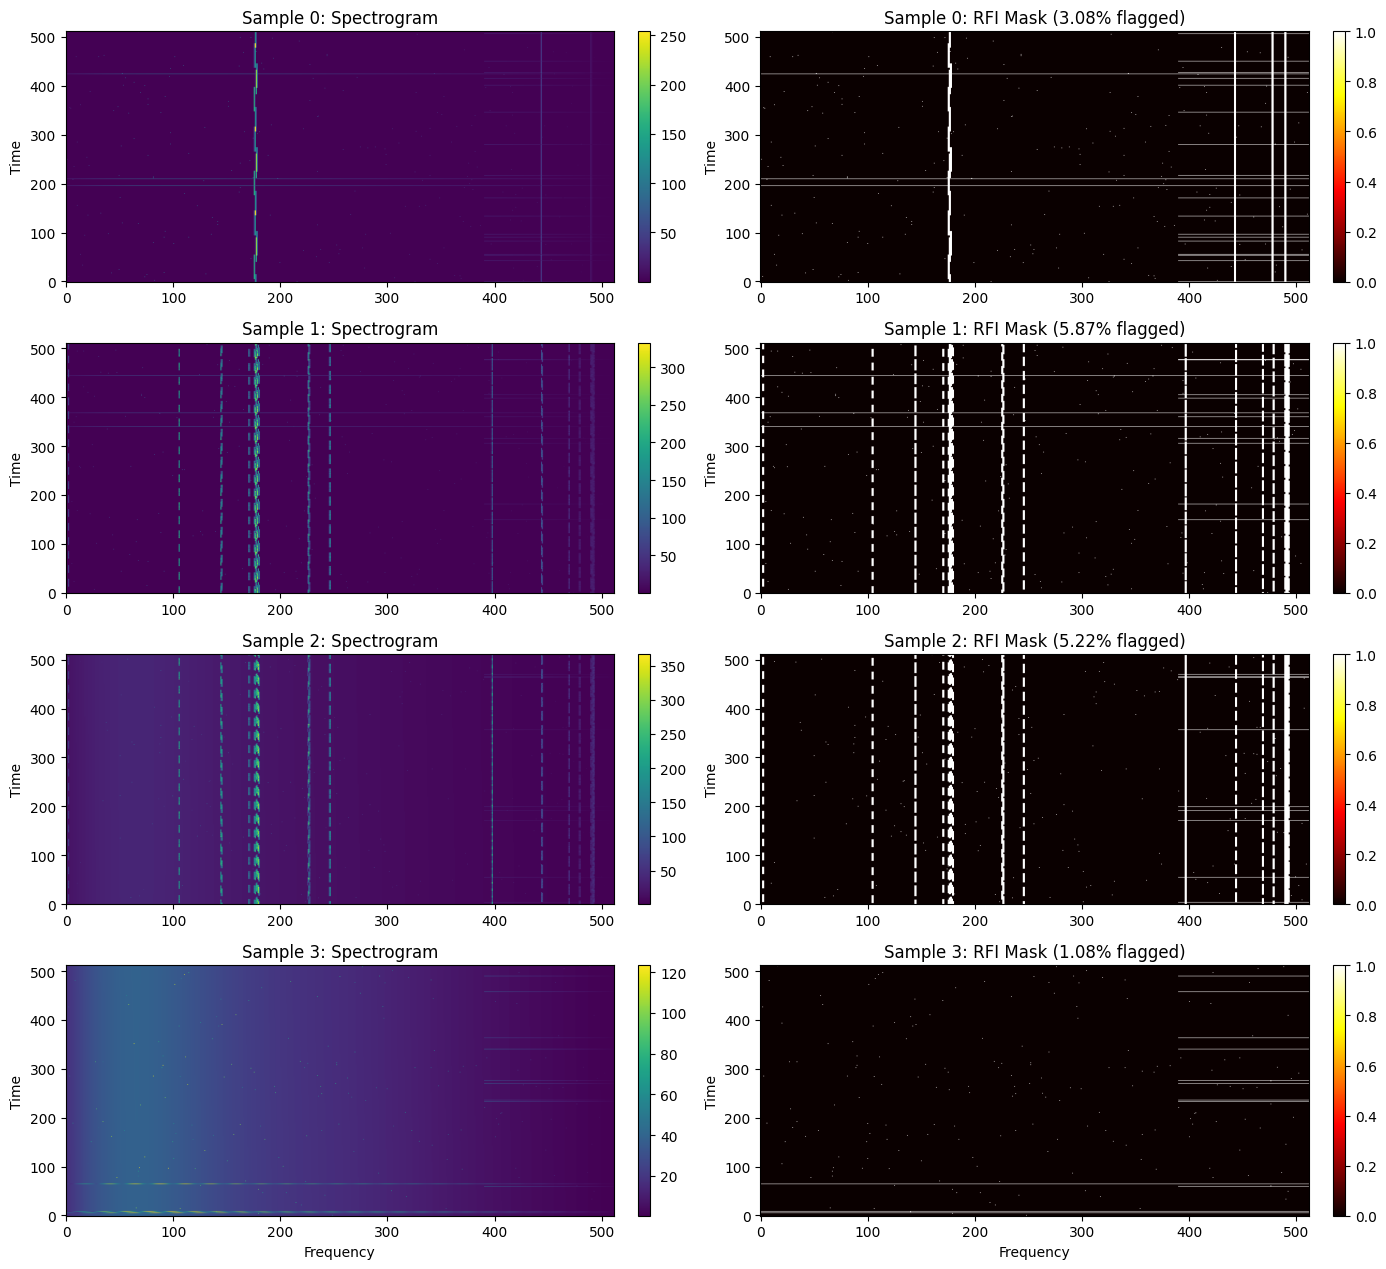

In [5]:
if isinstance(data, (list, tuple)) and len(data) >= 2 and isinstance(data[0], np.ndarray):
    num_samples = min(4, len(data[0]))
    fig, axes = plt.subplots(num_samples, 2, figsize=(14, 3.2 * num_samples))
    
    for i in range(num_samples):
        img_i = data[0][i].squeeze()
        msk_i = data[1][i].squeeze()
        
        im_sp = axes[i, 0].imshow(img_i, aspect="auto", cmap="viridis", origin="lower")
        axes[i, 0].set_title(f"Sample {i}: Spectrogram")
        axes[i, 0].set_ylabel("Time")
        fig.colorbar(im_sp, ax=axes[i, 0], fraction=0.046, pad=0.04)
        
        im_mk = axes[i, 1].imshow(msk_i, aspect="auto", cmap="hot", origin="lower")
        axes[i, 1].set_title(f"Sample {i}: RFI Mask ({100 * msk_i.mean():.2f}% flagged)")
        axes[i, 1].set_ylabel("Time")
        fig.colorbar(im_mk, ax=axes[i, 1], fraction=0.046, pad=0.04)
        
        if i == num_samples - 1:
            axes[i, 0].set_xlabel("Frequency")
            axes[i, 1].set_xlabel("Frequency")
            
    plt.tight_layout()
    plt.show()
